E-Library Data Insights Dashboard

In [11]:
# Cell 1: imports
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 120


In [2]:
# Cell 2: load dataset 
filename = "library_transactions.csv"

try:
    df = pd.read_csv(filename, parse_dates=["Date"])
    print(f"Loaded {filename}")
except Exception as e:
    print(f"Could not load {filename} ({e}). Creating a small sample dataset instead.")
    data = {
        "Transaction ID":[1,2,3,4,5,6],
        "Date":["2025-01-01","2025-01-05","2025-01-08","2025-01-12","2025-01-20","2025-01-25"],
        "User ID":[101,102,101,103,104,102],
        "Book Title":["Python","AI","Python","ML","Data Science","AI"],
        "Genre":["Programming","AI","Programming","AI","Data","AI"],
        "Borrowing Duration (Days)":[7,10,5,8,9,6]
    }
    df = pd.DataFrame(data)
    df["Date"] = pd.to_datetime(df["Date"])


df.head()


Could not load library_transactions.csv ([Errno 2] No such file or directory: 'library_transactions.csv'). Creating a small sample dataset instead.


,Transaction ID,Date,User ID,Book Title,Genre,Borrowing Duration (Days)
0,1,2025-01-01,101,Python,Programming,7
1,2,2025-01-05,102,AI,AI,10
2,3,2025-01-08,101,Python,Programming,5
3,4,2025-01-12,103,ML,AI,8
4,5,2025-01-20,104,Data Science,Data,9


In [12]:
# Cell 3:show miss detaset
print("Rows, Columns:", df.shape)
print("\nMissing values per column:\n", df.isna().sum())
df.dtypes


Rows, Columns: (6, 7)

Missing values per column:
 Transaction ID               0
Date                         0
User ID                      0
Book Title                   0
Genre                        0
Borrowing Duration (Days)    0
Weekday                      0
dtype: int64


Transaction ID                        int64
Date                         datetime64[ns]
User ID                               int64
Book Title                           object
Genre                                object
Borrowing Duration (Days)             int64
Weekday                              object
dtype: object

In [4]:
# Cell 4: basic stats
print("Top borrowed books:")
print(df["Book Title"].value_counts())

print("\nAverage borrowing duration (days):", round(df["Borrowing Duration (Days)"].mean(), 2))

df["Weekday"] = df["Date"].dt.day_name()
busiest = df["Weekday"].mode().iloc[0]
print("Busiest weekday:", busiest)


Top borrowed books:
Book Title
Python          2
AI              2
ML              1
Data Science    1
Name: count, dtype: int64

Average borrowing duration (days): 7.5
Busiest weekday: Sunday


In [13]:
# Cell 5: filtering 

genre = "AI"          # change to any genre (or set None)
start_date = "2025-01-01"  # or None
end_date = "2025-01-31"    # or None

filtered = df.copy()
if genre:
    filtered = filtered[filtered["Genre"].str.lower() == genre.lower()]
if start_date:
    filtered = filtered[filtered["Date"] >= pd.to_datetime(start_date)]
if end_date:
    filtered = filtered[filtered["Date"] <= pd.to_datetime(end_date)]

print(f"Filtered rows: {len(filtered)}")
filtered


Filtered rows: 3


,Transaction ID,Date,User ID,Book Title,Genre,Borrowing Duration (Days),Weekday
1,2,2025-01-05,102,AI,AI,10,Sunday
3,4,2025-01-12,103,ML,AI,8,Sunday
5,6,2025-01-25,102,AI,AI,6,Saturday


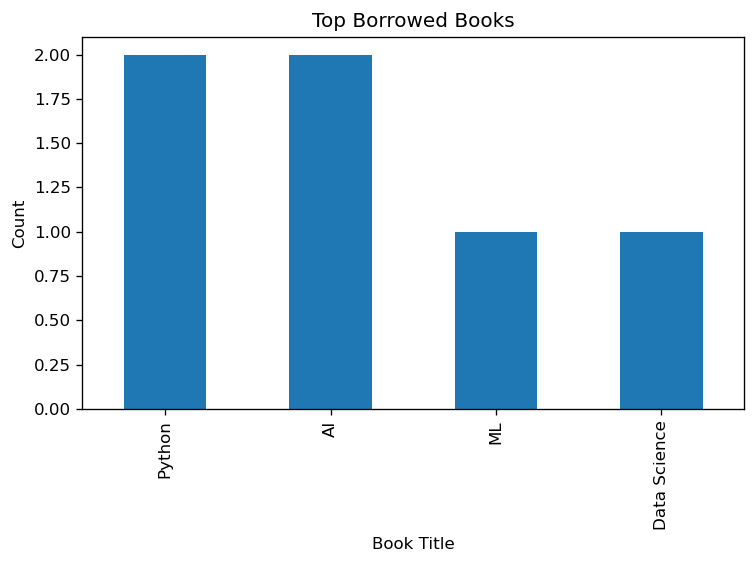

In [6]:
# Cell 6: bar chart
counts = df["Book Title"].value_counts()
counts.plot(kind="bar")
plt.title("Top Borrowed Books")
plt.xlabel("Book Title")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


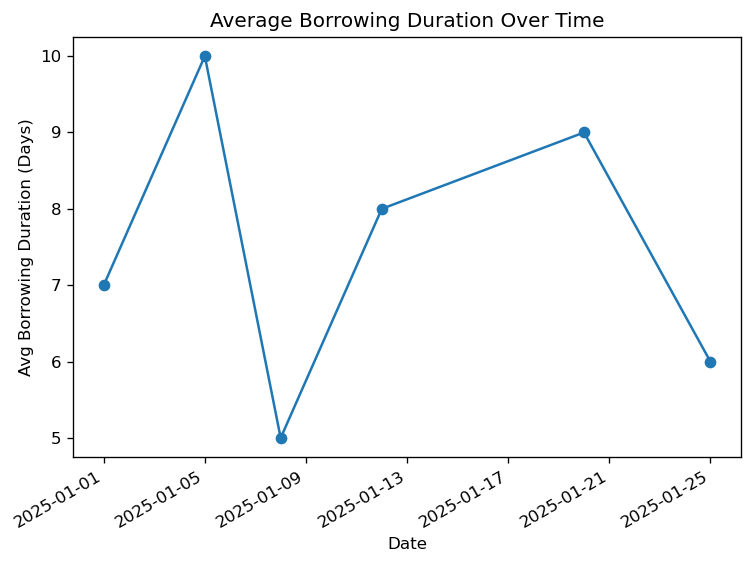

In [7]:
# Cell 7: line chart 
avg_per_date = df.groupby("Date")["Borrowing Duration (Days)"].mean()
avg_per_date.plot(kind="line", marker="o")
plt.title("Average Borrowing Duration Over Time")
plt.xlabel("Date")
plt.ylabel("Avg Borrowing Duration (Days)")
plt.tight_layout()
plt.show()


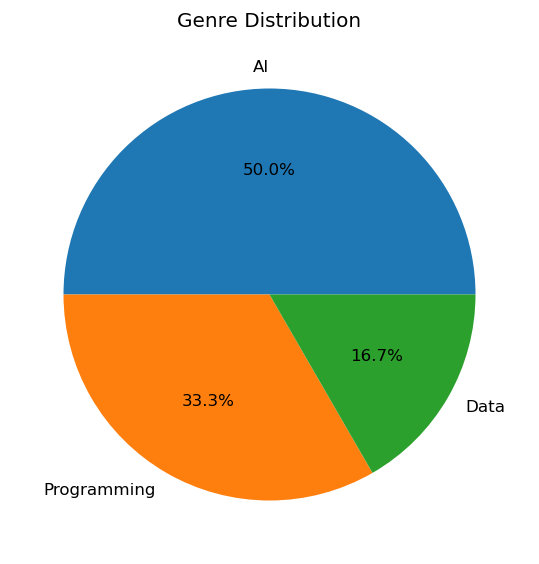

In [8]:
# Cell 8: pie chart
df["Genre"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Genre Distribution")
plt.ylabel("")  # hide y-label
plt.tight_layout()
plt.show()


In [7]:
# Make sure Date column is datetime
df["Date"] = pd.to_datetime(df["Date"])

# Create a weekday column
df["Weekday"] = df["Date"].dt.day_name()

# Create the pivot table for heatmap
heatmap_data = df.pivot_table(index="Weekday", columns="Genre", 
                              values="Transaction ID", aggfunc="count", fill_value=0)

# Optional: reorder weekdays
ordered_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_data = heatmap_data.reindex(ordered_days)


<Figure size 960x600 with 0 Axes>

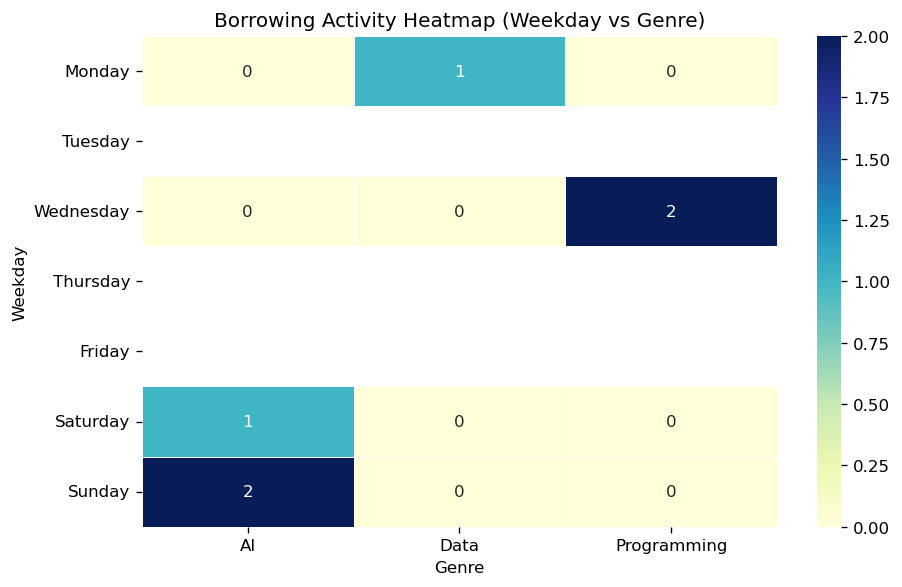

In [8]:
#cell:9 heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", linewidths=0.5)
plt.title("Borrowing Activity Heatmap (Weekday vs Genre)")
plt.xlabel("Genre")
plt.ylabel("Weekday")
plt.tight_layout()
plt.show()


In [10]:
# Cell 10: save filtered results or full dataset
filtered.to_csv("filtered_library_transactions.csv", index=False)
print("Saved filtered_library_transactions.csv")


NameError: name 'filtered' is not defined